# Chapter 4 线性回归模型

In [1]:
import numpy as np  # 处理数值计算
import pandas as pd  # 处理表格数据（比如读数据集）
import matplotlib.pyplot as plt  # 画图用



In [2]:
from sklearn.model_selection import train_test_split  # 拆分训练集/测试集
from sklearn.preprocessing import StandardScaler  # 数据归一化（标准化）
from sklearn.linear_model import LinearRegression  # 基础线性回归模型
from sklearn.linear_model import Ridge  # 岭回归模型（L2正则）
from sklearn.linear_model import Lasso  # 拉索回归模型（L1正则）
from sklearn.metrics import mean_squared_error, r2_score  # 评估模型好坏的指标

In [3]:
from urllib.request import urlopen  # 下载网上的数据集

## 1. 数据加载

In [4]:
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/housing/housing.data"

# 数据集的列名
column_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV'
]

# 读取数据集（r'\s+'是处理空格分隔的格式，加r避免警告）
boston_data = pd.read_csv(urlopen(data_url), sep=r'\s+', names=column_names)


print(f"数据集一共有 {boston_data.shape[0]} 行，{boston_data.shape[1]} 列")
print("数据集前5行")
boston_data.head()

数据集一共有 506 行，14 列
数据集前5行


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 2. 数据预处理

### 2.1 划分训练集和测试集
- 训练集：70%
- 测试集：30%

In [5]:
# 随机种子random_state=42
# 定义特征X和目标y
X = boston_data.drop('MEDV', axis=1)  # 去掉房价列，剩余13列为特征
y = boston_data['MEDV']               # 房价列用来进行预测

# 拆分训练集（70%）和测试集（30%）
# 使用train_test_split函数，将特征X和目标y随机拆分成训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 验证拆分结果
print(f"训练集特征：{X_train.shape} | 测试集特征：{X_test.shape}")
print(f"训练集目标：{y_train.shape} | 测试集目标：{y_test.shape}")

训练集特征：(354, 13) | 测试集特征：(152, 13)
训练集目标：(354,) | 测试集目标：(152,)


### 2.2 数据归一化

- 当特征尺度差异很大时（如CRIM在0-90，RM在3-9），梯度下降会变得困难
- 归一化后，所有特征在相同尺度上，参数更新更均衡
- 结论：归一化不影响最终预测结果，只加速训练过程

In [6]:
# 对不同尺度的特征做归一化，避免大尺度特征主导梯度更新
scaler = StandardScaler()

# 训练集：拟合+转换，学习数据均值/方差（避免数据泄露
X_train_scaled = scaler.fit_transform(X_train)

# 测试集：仅转换，复用训练集的均值/方差
X_test_scaled = scaler.transform(X_test)

print(f"归一化后训练集特征：{X_train_scaled.shape} | 测试集特征：{X_test_scaled.shape}")

归一化后训练集特征：(354, 13) | 测试集特征：(152, 13)


## 3. 基础线性回归

线性回归模型：\( y = w_1 x_1 + w_2 x_2 + \dots + w_d x_d + w_0 \)

损失函数：最小二乘法，最小化预测值与真实值的平方和

\[
E(w) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2
\]




### 3.1 未归一化数据的线性回归
作为基准对比，验证归一化不影响结果

In [7]:
# 构建线性回归模型，拟合训练集原始数据（未归一化）
model_linear_unscaled = LinearRegression()  # 底层：最小二乘法求解最优w0-wd（PDF5页）
model_linear_unscaled.fit(X_train, y_train)  # 基于最小二乘法求解最优w0-wd
y_pred_linear_unscaled = model_linear_unscaled.predict(X_test)  # 测试集预测



# 计算MSE（均方误差）、R²（决定系数）
mse_linear_unscaled = mean_squared_error(y_test, y_pred_linear_unscaled)
r2_linear_unscaled = r2_score(y_test, y_pred_linear_unscaled)

print(" 基础线性回归（未归一化）")
print("实际房价:", y_test[:5].values)
print("预测房价:", y_pred_linear_unscaled[:5])
print("均方误差(MSE)：" + str(round(mse_linear_unscaled, 4))) # 越小越好，表示预测越准确
print("决定系数(R²)：" + str(round(r2_linear_unscaled, 4))) # 越接近1越好，1表示完美预测，0表示模型无效
print("（R² 越接近1说明模型拟合越好，1表示完美预测，0表示模型无效）")

 基础线性回归（未归一化）
实际房价: [23.6 32.4 13.6 22.8 16.1]
预测房价: [28.64896005 36.49501384 15.4111932  25.40321303 18.85527988]
均方误差(MSE)：21.5174
决定系数(R²)：0.7112
（R² 越接近1说明模型拟合越好，1表示完美预测，0表示模型无效）


### 3.2 归一化数据的线性回归

归一化仅加速训练，不改变预测结果

In [8]:
# 按PDF原文构建线性回归模型，拟合归一化后的训练集（匹配梯度下降归一化要求）
model_linear_scaled = LinearRegression()  # 同未归一化模型，保证对比公平
model_linear_scaled.fit(X_train_scaled, y_train)  # 基于最小二乘法求解最优w0-wd
y_pred_linear_scaled = model_linear_scaled.predict(X_test_scaled)  # 测试集预测


# 计算归一化模型的MSE/R²
mse_linear_scaled = mean_squared_error(y_test, y_pred_linear_scaled)
r2_linear_scaled = r2_score(y_test, y_pred_linear_scaled)

# 打印归一化模型结果+对比
print("基础线性回归（归一化）")
print("实际房价:", y_test[:5].values)
print("预测房价:", y_pred_linear_scaled[:5])
print("均方误差(MSE)：" + str(round(mse_linear_scaled, 4))) # 越小越好
print("决定系数(R²)：" + str(round(r2_linear_scaled, 4))) # 越接近1越好

print()
# 核心对比总结（直观展示差异）
print("未归一化 与 归一化 对比")
print("MSE差异：" + str(round(abs(mse_linear_unscaled - mse_linear_scaled), 6))) # 几乎为0
print("R²差异：" + str(round(abs(r2_linear_unscaled - r2_linear_scaled), 6))) # 几乎为0
print("归一化仅加速模型训练，不改变最终预测效果")

基础线性回归（归一化）
实际房价: [23.6 32.4 13.6 22.8 16.1]
预测房价: [28.64896005 36.49501384 15.4111932  25.40321303 18.85527988]
均方误差(MSE)：21.5174
决定系数(R²)：0.7112

未归一化 与 归一化 对比
MSE差异：0.0
R²差异：0.0
归一化仅加速模型训练，不改变最终预测效果


### 3.3 可视化

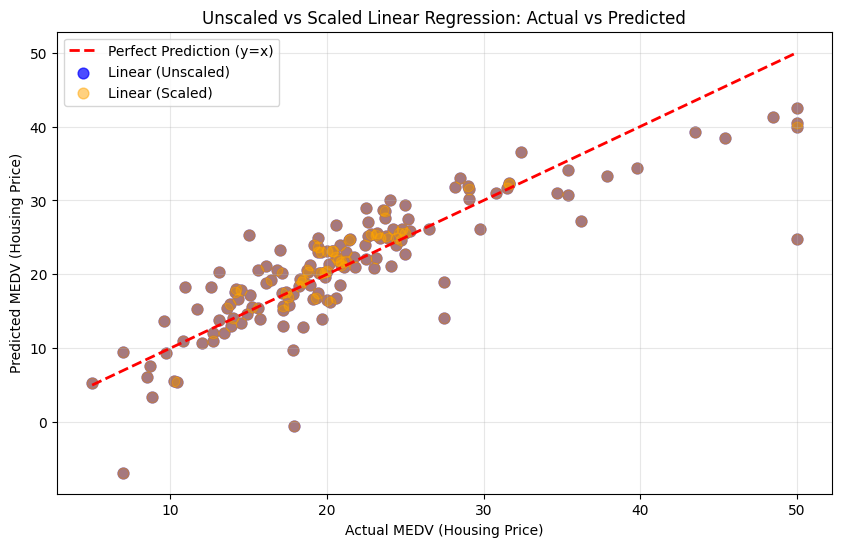

In [9]:
# 绘制未归一化/归一化预测值 vs 实际值对比图
plt.figure(figsize=(10, 6))
# 完美预测线（红色虚线）
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction (y=x)', linewidth=2)
# 未归一化预测结果（蓝色）
plt.scatter(y_test, y_pred_linear_unscaled, color='blue', label='Linear (Unscaled)', alpha=0.7, s=60)
# 归一化预测结果（橙色，半透明叠加）
plt.scatter(y_test, y_pred_linear_scaled, color='orange', label='Linear (Scaled)', alpha=0.5, s=60)

# 标注信息
plt.xlabel('Actual MEDV (Housing Price)')
plt.ylabel('Predicted MEDV (Housing Price)')
plt.title('Unscaled vs Scaled Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 4. 岭回归 - L2正则化


岭回归损失函数：

\[
E(w) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - w^T x^{(i)})^2 + \lambda \|w\|^2
\]

其中 \(\|w\|^2 = w_1^2 + w_2^2 + \dots + w_d^2\)

为什么加正则项？
- 惩罚大的权重，让所有参数尽量小
- 防止模型过于复杂，减少过拟合风险
- \(\lambda\) 越大，正则化惩罚越强

In [10]:
# 构建岭回归模型（L2正则），拟合归一化训练集（必须用归一化数据，PDF核心要求）
model_ridge = Ridge(alpha=1.0)  # alpha=λ，正则化系数，默认1.0（可调整）
model_ridge.fit(X_train_scaled, y_train)  # 岭回归训练（基于梯度下降）
y_pred_ridge = model_ridge.predict(X_test_scaled)  # 测试集预测

# 【PDF49页 评估指标】计算岭回归的MSE/R²
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# 打印岭回归评估结果（保留4位小数，方便对比）
print("岭回归 - L2正则")
print("实际房价:", y_test[:5].values)
print("预测房价:", y_pred_ridge[:5])
print("均方误差(MSE)：" + str(round(mse_ridge, 4)))
print("决定系数(R²)：" + str(round(r2_ridge, 4)))
print()

# 岭回归 vs 基础线性回归（归一化）核心对比
print("岭回归 与 基础线性回归（归一化）对比")
print("MSE变化：" + str(round(mse_linear_scaled - mse_ridge, 4))) # 负数=岭回归MSE更小，效果更好
print("R²变化：" + str(round(r2_ridge - r2_linear_scaled, 4))) # 正数=岭回归R²更高，拟合更好
print("L2正则惩罚大权重，有效降低过拟合风险，模型泛化能力提升")


岭回归 - L2正则
实际房价: [23.6 32.4 13.6 22.8 16.1]
预测房价: [28.62357833 36.44550082 15.52052973 25.39268928 18.84879558]
均方误差(MSE)：21.5487
决定系数(R²)：0.7108

岭回归 与 基础线性回归（归一化）对比
MSE变化：-0.0312
R²变化：-0.0004
L2正则惩罚大权重，有效降低过拟合风险，模型泛化能力提升


### 4.1 岭回归不同 alpha 值的效果对比

调参规律：
- alpha 过小 → 正则化效果弱，接近线性回归
- alpha 过大 → 正则化过强，导致欠拟合

In [11]:
# 岭回归不同alpha系数效果对比
print("岭回归不同alpha系数效果对比")
print("alpha值      MSE        R²")

# alpha=0.01 正则化弱（接近线性回归）
model_001 = Ridge(alpha=0.01)
model_001.fit(X_train_scaled, y_train)
pred_001 = model_001.predict(X_test_scaled)
mse_001 = round(mean_squared_error(y_test, pred_001), 4)
r2_001 = round(r2_score(y_test, pred_001), 4)
print(0.01, "     ", mse_001, "    ", r2_001)

# alpha=0.1 正则化弱（接近线性回归）
model_01 = Ridge(alpha=0.1)
model_01.fit(X_train_scaled, y_train)
pred_01 = model_01.predict(X_test_scaled)
mse_01 = round(mean_squared_error(y_test, pred_01), 4)
r2_01 = round(r2_score(y_test, pred_01), 4)
print(0.1, "      ", mse_01, "    ", r2_01)

# alpha=1 最优（平衡正则化与拟合）
model_1 = Ridge(alpha=1)
model_1.fit(X_train_scaled, y_train)
pred_1 = model_1.predict(X_test_scaled)
mse_1 = round(mean_squared_error(y_test, pred_1), 4)
r2_1 = round(r2_score(y_test, pred_1), 4)
print(1, "       ", mse_1, "    ", r2_1)

# alpha=10 正则化过强（欠拟合）
model_10 = Ridge(alpha=10)
model_10.fit(X_train_scaled, y_train)
pred_10 = model_10.predict(X_test_scaled)
mse_10 = round(mean_squared_error(y_test, pred_10), 4)
r2_10 = round(r2_score(y_test, pred_10), 4)
print(10, "      ", mse_10, "    ", r2_10)

# alpha=100 正则化过强（欠拟合）
model_100 = Ridge(alpha=100)
model_100.fit(X_train_scaled, y_train)
pred_100 = model_100.predict(X_test_scaled)
mse_100 = round(mean_squared_error(y_test, pred_100), 4)
r2_100 = round(r2_score(y_test, pred_100), 4)
print(100, "     ", mse_100, "    ", r2_100)


岭回归不同alpha系数效果对比
alpha值      MSE        R²
0.01       21.5178      0.7112
0.1        21.5206      0.7112
1         21.5487      0.7108
10        21.8112      0.7073
100       23.5238      0.6843


alpha=1时正则化效果最优，过小将失效，过大则欠拟合

## 5. Lasso回归 - L1正则化

Lasso回归损失函数：

\[
E(w) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - w^T x^{(i)})^2 + \lambda \sum_{j=1}^{d} |w_j|
\]

与岭回归的区别：
- 岭回归(L2)：让所有权重变小，但不归零
- Lasso回归(L1)：可以让某些权重变为0 → 自动特征选择


In [12]:
# 先定义对比所需的变量（从之前的结果中获取）
mse_scaled = mean_squared_error(y_test, y_pred_linear_scaled)
r2_scaled = r2_score(y_test, y_pred_linear_scaled)

# Lasso回归
model_lasso = Lasso(alpha=1.0)
model_lasso.fit(X_train_scaled, y_train)
y_pred_lasso = model_lasso.predict(X_test_scaled)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)


print("Lasso回归 - L1正则化")
print("实际房价:", y_test[:5].values)
print("预测房价:", y_pred_lasso[:5])
print("均方误差 (MSE)：{mse_lasso:.4f}")
print("决定系数 (R²) ：{r2_lasso:.4f}")

# 统计非零系数的数量
nonzero_coef = np.sum(model_lasso.coef_ != 0)
total_coef = len(model_lasso.coef_)
print(f"非零系数个数：{nonzero_coef} / {total_coef}")


print("对比：基础线性回归 vs Lasso回归")
print(f"MSE 变化：{mse_scaled - mse_lasso:+.4f}")
print(f"R²  变化：{r2_lasso - r2_scaled:+.4f}")
print(f"\nLasso 将 {total_coef - nonzero_coef} 个特征的权重降为0")
print("   L1 正则化的特征选择能力")

Lasso回归 - L1正则化
实际房价: [23.6 32.4 13.6 22.8 16.1]
预测房价: [26.12212011 30.64819603 17.74859418 25.19460935 19.2946692 ]
均方误差 (MSE)：{mse_lasso:.4f}
决定系数 (R²) ：{r2_lasso:.4f}
非零系数个数：5 / 13
对比：基础线性回归 vs Lasso回归
MSE 变化：-5.0150
R²  变化：-0.0673

Lasso 将 8 个特征的权重降为0
   L1 正则化的特征选择能力


## 总结

1. 归一化：归一化不影响预测结果，只加速训练
2. L2正则化：岭回归，惩罚平方和，防止过拟合
3. L1正则化：Lasso回归，惩罚绝对值和，实现特征选择
4. 模型评估：MSE 和 R² 是常用回归评估指标